In [27]:
# CREDIT CARD FRAUD DETECTION PROJECT 

# 1. IMPORTING LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [28]:
# 2. LOADING DATASET
df = pd.read_csv(r"C:\Users\A S U S\aidi-1204-project\My project\credit_card_transactions.csv\credit_card_transactions.csv")

In [30]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0


In [32]:
df.isnull().sum()

Unnamed: 0                    0
trans_date_trans_time         0
cc_num                        0
merchant                      0
category                      0
amt                           0
first                         0
last                          0
gender                        0
street                        0
city                          0
state                         0
zip                           0
lat                           0
long                          0
city_pop                      0
job                           0
dob                           0
trans_num                     0
unix_time                     0
merch_lat                     0
merch_long                    0
is_fraud                      0
merch_zipcode            195973
dtype: int64

In [38]:
df.drop(['Unnamed: 0', 'merch_zipcode'], axis=1, inplace=True)

In [34]:
df['is_fraud'].value_counts()

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

<Axes: >

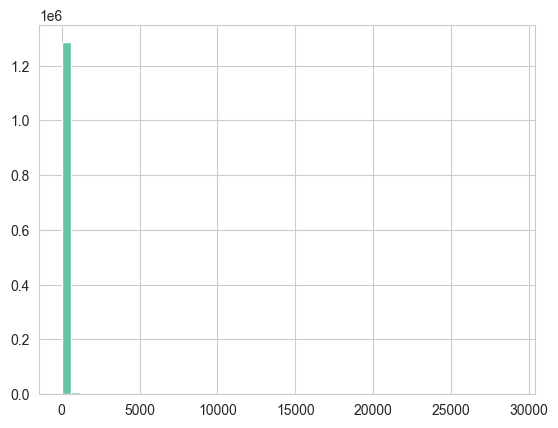

In [36]:
df['amt'].hist(bins=50)

In [39]:
df.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud'],
      dtype='str')

In [42]:
df.rename(columns={'trans_date_trans_time': 'trans_date_time',
                   'cc_num':'credit_card_number',
                   'amt' : 'amount',
                   } ,inplace=True)

In [43]:
df

,trans_date_time,credit_card_number,merchant,category,amount,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,Hatch,...,37.7175,-112.4777,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0
1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,Tuscarora,...,39.2667,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0
1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,High Rolls Mountain Park,...,32.9396,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0
1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,Manderson,...,43.3526,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0


<Axes: xlabel='is_fraud', ylabel='amount'>

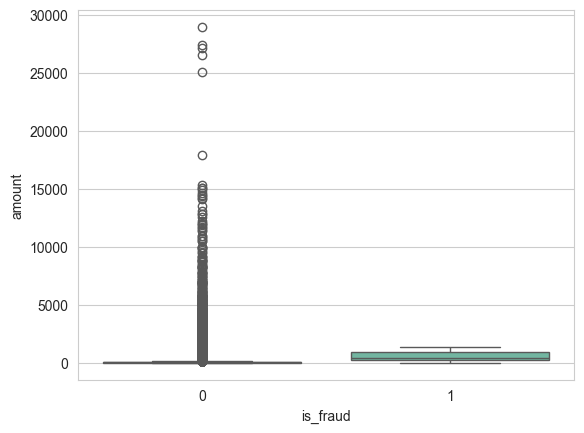

In [44]:
import seaborn as sns
sns.boxplot(x='is_fraud', y='amount', data=df)

In [48]:
df['trans_date_time']=pd.to_datetime(df['trans_date_time'])
df['trans_hour']=df['trans_date_time'].dt.hour

In [50]:
df.groupby('trans_hour')['is_fraud'].mean()

trans_hour
0     0.014940
1     0.015349
2     0.014652
3     0.014239
4     0.001099
5     0.001423
6     0.000946
7     0.001327
8     0.001153
9     0.001114
10    0.000946
11    0.000998
12    0.001027
13    0.001225
14    0.001325
15    0.001208
16    0.001156
17    0.001192
18    0.001226
19    0.001236
20    0.000952
21    0.001129
22    0.028829
23    0.028374
Name: is_fraud, dtype: float64

In [72]:
cols_to_drop = [
    'trans_date_time',
    'credit_card_number',
    'merchant',
    'first',
    'last',
    'street',
    'city',
    'zip',
    'job',
    'trans_num',
    'unix_time'
]

df = df.drop(columns=cols_to_drop, errors='ignore')

In [73]:
df

,category,amount,gender,state,lat,long,city_pop,dob,merch_lat,merch_long,is_fraud,trans_hour
0,misc_net,4.97,F,NC,36.0788,-81.1781,3495,1988-03-09,36.011293,-82.048315,0,0
1,grocery_pos,107.23,F,WA,48.8878,-118.2105,149,1978-06-21,49.159047,-118.186462,0,0
2,entertainment,220.11,M,ID,42.1808,-112.2620,4154,1962-01-19,43.150704,-112.154481,0,0
3,gas_transport,45.00,M,MT,46.2306,-112.1138,1939,1967-01-12,47.034331,-112.561071,0,0
4,misc_pos,41.96,M,VA,38.4207,-79.4629,99,1986-03-28,38.674999,-78.632459,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,entertainment,15.56,M,UT,37.7175,-112.4777,258,1961-11-24,36.841266,-111.690765,0,12
1296671,food_dining,51.70,M,MD,39.2667,-77.5101,100,1979-12-11,38.906881,-78.246528,0,12
1296672,food_dining,105.93,M,NM,32.9396,-105.8189,899,1967-08-30,33.619513,-105.130529,0,12
1296673,food_dining,74.90,M,SD,43.3526,-102.5411,1126,1980-08-18,42.788940,-103.241160,0,12


In [74]:
#Feature Engineering 
#DOB to age

df['dob'] = pd.to_datetime(df['dob'])
df['age'] = 2020 - df['dob'].dt.year
df = df.drop(columns=['dob'])

In [ ]:
#Create DISTANCE feature
df['distance'] = ((df['lat'] - df['merch_lat'])**2 + 
                  (df['long'] - df['merch_long'])**2)**0.5 #calculating euclidean distance

In [76]:
#Gender encoding
df['gender'] = df['gender'].map({'M': 1, 'F': 0})

In [77]:
#category encoding
df = pd.get_dummies(df, columns=['category'], drop_first=True)

In [79]:
#Main Feature:
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']


In [87]:
df['state'].value_counts()

state
NY    178316
TX    176830
PA    158244
CA    112174
OH    101270
FL     90721
MI     86933
IL     85823
AL     77599
MO     70626
MN     67104
VA     63174
SC     62191
AR     58532
WI     57002
NC     55670
KY     55137
NE     54833
MD     53095
IN     51646
OK     51290
GA     51031
IA     51008
WV     50474
KS     49501
NJ     44690
OR     44013
TN     41238
MS     41071
WY     38011
ME     37033
LA     36532
WA     35207
CO     33148
NM     30302
SD     25190
ND     24491
MA     24134
VT     23958
UT     21154
NH     18364
MT     17249
AZ     17051
NV     13692
CT     10363
AK      8241
ID      7494
DC      7230
HI      3716
RI      3068
DE      1474
Name: count, dtype: int64

In [ ]:
#Feature encoding done for state
df = pd.get_dummies(df, columns=['state'], drop_first=True)

In [89]:
df

,amount,gender,lat,long,city_pop,merch_lat,merch_long,is_fraud,trans_hour,age,...,state_SD,state_TN,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY
0,4.97,0,36.0788,-81.1781,3495,36.011293,-82.048315,0,0,32,...,False,False,False,False,False,False,False,False,False,False
1,107.23,0,48.8878,-118.2105,149,49.159047,-118.186462,0,0,42,...,False,False,False,False,False,False,True,False,False,False
2,220.11,1,42.1808,-112.2620,4154,43.150704,-112.154481,0,0,58,...,False,False,False,False,False,False,False,False,False,False
3,45.00,1,46.2306,-112.1138,1939,47.034331,-112.561071,0,0,53,...,False,False,False,False,False,False,False,False,False,False
4,41.96,1,38.4207,-79.4629,99,38.674999,-78.632459,0,0,34,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
746785,956.44,0,40.7559,-82.5123,92985,41.429801,-83.158234,1,23,52,...,False,False,False,False,False,False,False,False,False,False
1170519,302.24,1,33.7163,-116.3381,4677,34.535380,-117.095446,1,22,65,...,False,False,False,False,False,False,False,False,False,False
1167025,284.16,0,41.2496,-73.9446,3487,41.846303,-74.280385,1,11,60,...,False,False,False,False,False,False,False,False,False,False
1158319,320.24,0,34.7543,-86.6546,190178,34.961498,-85.869041,1,0,90,...,False,False,False,False,False,False,False,False,False,False


In [83]:
#handling imbalance
from sklearn.utils import resample

df_majority = df[df.is_fraud == 0]
df_minority = df[df.is_fraud == 1]

df_minority_upsampled = resample(df_minority,
                                 replace=True,
                                 n_samples=len(df_majority),
                                 random_state=42)

df = pd.concat([df_majority, df_minority_upsampled])

In [94]:
#Training Model

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [95]:
#prediction
y_pred = model.predict(X_test)

In [96]:
#performance checking 
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9592683664683479
              precision    recall  f1-score   support

           0       0.95      0.97      0.96    257754
           1       0.97      0.95      0.96    257914

    accuracy                           0.96    515668
   macro avg       0.96      0.96      0.96    515668
weighted avg       0.96      0.96      0.96    515668



[[250678   7076]
 [ 13928 243986]]


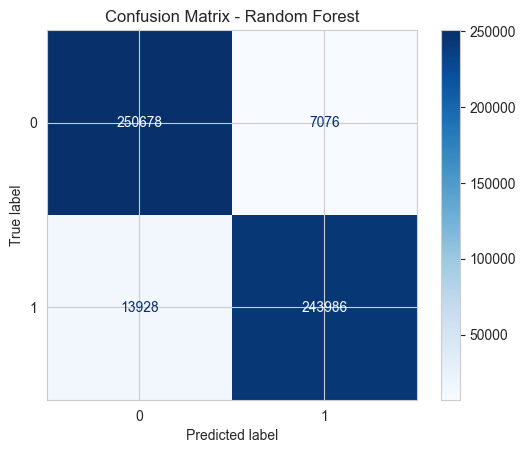

In [97]:
#confusion matrix 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [98]:
#displaying the confusion matrix values
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 250678
False Positives: 7076
False Negatives: 13928
True Positives: 243986


-True Negatives = normal transactions correctly identified

-False Positives = normal transactions wrongly flagged as fraud

-False Negatives = fraud transactions missed by the model

-True Positives = fraud transactions correctly caught

In [103]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

log_model = LogisticRegression(max_iter=500, solver='liblinear', class_weight='balanced', random_state=42)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred_log))

Confusion Matrix:
[[244888  12866]
 [ 63331 194583]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.95      0.87    257754
           1       0.94      0.75      0.84    257914

    accuracy                           0.85    515668
   macro avg       0.87      0.85      0.85    515668
weighted avg       0.87      0.85      0.85    515668


Accuracy:
0.8522363225951581
